In [4]:
# This cell imports libraries for loading Marc's dataset, preprocessing descriptions, TF-IDF, SVD, plotting, and saving files.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import html
import contractions
import nltk
import os

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/brittanyuy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [5]:
# This cell loads Marc's updated TTRPG dataset.

marc_df = pd.read_csv("../marc/ttrpg_cleaned.csv")

print("Marc dataset shape:", marc_df.shape)
print("Columns:", marc_df.columns.tolist())

marc_df.head()

Marc dataset shape: (5000, 6)
Columns: ['Name', 'Description', 'Average Score', 'Number of Reviews', 'Category', 'Mechanics']


,Name,Description,Average Score,Number of Reviews,Category,Mechanics
0,Battlesystem Game Skirmishes,"A companion to the Battlesystem game, this boo...",6.13636,11,Fantasy (High Fantasy),"Alternate Rules (Variant Core Rules), Sourcebo..."
1,DM Toolkit,DM Toolkit is the ultimate resource for Dungeo...,10.00000,1,Fantasy,"Accessory (dice, maps, screens, cards), Softwa..."
2,Luftwaffe 1946 Roleplaying Game,From the Battlefield Press website - Total war...,4.00000,1,War,Core Rules (min needed to play)
3,Adolf Hitler - Porn Star,"Publisher's blurb: ""Adolf Hitler - Porn Star i...",2.00000,2,Comedy / Satire,Scenario / Adventure / Module
4,Cthulhu Britannica: London,London in the 1920s is the greatest city in th...,9.25000,10,Horror (Cthulhu Mythos),Sourcebook (rules/options to enhance play)


In [6]:
# This cell cleans the rows needed for description-based SVD.
# We only need Name and Description to exist for the SVD process.

marc_df = marc_df.dropna(subset=["Name", "Description"]).copy()

marc_df["Name"] = marc_df["Name"].astype(str)
marc_df["Description"] = marc_df["Description"].astype(str)

marc_df = marc_df[
    marc_df["Description"].str.strip() != ""
].copy()

# Convert score/review columns to numeric if they exist.
if "Average Score" in marc_df.columns:
    marc_df["Average Score"] = pd.to_numeric(marc_df["Average Score"], errors="coerce")

if "Number of Reviews" in marc_df.columns:
    marc_df["Number of Reviews"] = pd.to_numeric(marc_df["Number of Reviews"], errors="coerce")

print("Cleaned Marc dataset shape:", marc_df.shape)

marc_df.head()

Cleaned Marc dataset shape: (5000, 6)


,Name,Description,Average Score,Number of Reviews,Category,Mechanics
0,Battlesystem Game Skirmishes,"A companion to the Battlesystem game, this boo...",6.13636,11,Fantasy (High Fantasy),"Alternate Rules (Variant Core Rules), Sourcebo..."
1,DM Toolkit,DM Toolkit is the ultimate resource for Dungeo...,10.00000,1,Fantasy,"Accessory (dice, maps, screens, cards), Softwa..."
2,Luftwaffe 1946 Roleplaying Game,From the Battlefield Press website - Total war...,4.00000,1,War,Core Rules (min needed to play)
3,Adolf Hitler - Porn Star,"Publisher's blurb: ""Adolf Hitler - Porn Star i...",2.00000,2,Comedy / Satire,Scenario / Adventure / Module
4,Cthulhu Britannica: London,London in the 1920s is the greatest city in th...,9.25000,10,Horror (Cthulhu Mythos),Sourcebook (rules/options to enhance play)


In [7]:
# This cell defines the text preprocessing function for descriptions.
# It fixes HTML symbols, expands contractions, tokenizes, removes stopwords, keeps alphabetic words, and lemmatizes.

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_nltk_alpha_only(text):
    text = html.unescape(str(text))
    text = contractions.fix(text)

    tokens = word_tokenize(text.lower())

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word.isalpha() and word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [8]:
# This cell preprocesses only the Description column.
# This is the only text that will go into TF-IDF and SVD.

descs = marc_df["Description"].astype(str).tolist()

processed_descriptions = [
    preprocess_nltk_alpha_only(doc)
    for doc in descs
]

print("Number of processed descriptions:", len(processed_descriptions))

processed_descriptions[:3]

Number of processed descriptions: 5000


['companion battlesystem game book cover battle larger scale practical full rule use miniature game extensive rule gladiatorial contest campaign included newly revised rule allow much greater expansion tabletop fantasy army battle',
 'toolkit ultimate resource dungeon master lead storyteller game master ilk toolkit tool developed game master game master eliminates need storyteller carry enormous binder obscure information give mean work campaign spare moment try sure love even run ipad app come preloaded template dungeon dragon edition additionally new template content downloaded anytime suit need list free downloads increasing daily feature modify trap treasure gear character monster handheld device easily reference data build encounter dungeon keep note add picture completely customize resource preloaded dnd edition template quick startup template system allows user add new original game system app download free template additional game system download free library content expand exi

In [9]:
# This cell converts only the processed descriptions into a TF-IDF matrix.
# This TF-IDF matrix is the actual input to SVD.

tfidf_vectorizer_marc = TfidfVectorizer(
    token_pattern=r"\w+",
    lowercase=True,
    min_df=5,
)

X_tfidf_marc = tfidf_vectorizer_marc.fit_transform(processed_descriptions)

print("TF-IDF shape from Description only:", X_tfidf_marc.shape)

TF-IDF shape from Description only: (5000, 7104)


In [10]:
# This cell fits TruncatedSVD on the TF-IDF matrix made from descriptions only.
# We are not applying SVD to the full dataset.

max_components = min(
    5000,
    X_tfidf_marc.shape[0] - 1,
    X_tfidf_marc.shape[1] - 1
)

svd_marc = TruncatedSVD(
    n_components=max_components,
    random_state=42
)

svd_marc.fit(X_tfidf_marc)

print("SVD fitted with components:", max_components)

SVD fitted with components: 4999


In [11]:
# This cell finds how many singular values are needed to reach 90% explained variance.

energy_marc = svd_marc.singular_values_**2
energy_ratio_marc = energy_marc / energy_marc.sum()
energy_ratio_cumsum_marc = energy_ratio_marc.cumsum()

marc_svs = None

for i in range(len(energy_ratio_cumsum_marc)):
    if energy_ratio_cumsum_marc[i] >= 0.90:
        marc_svs = i + 1
        print(f"Explained variance at {marc_svs} SVs: {energy_ratio_cumsum_marc[i]:.2f}")
        break

if marc_svs is None:
    print(f"Did not reach 0.90. Max explained variance: {energy_ratio_cumsum_marc[-1]:.2f}")

Explained variance at 1095 SVs: 0.90


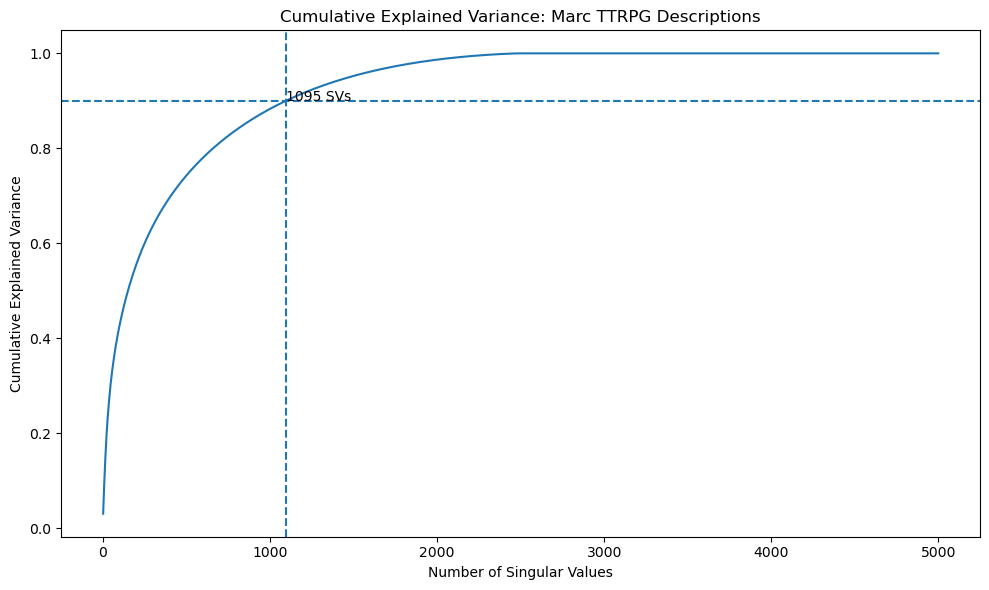

In [12]:
# This cell plots cumulative explained variance and marks the 90% threshold.

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(energy_ratio_cumsum_marc) + 1),
    energy_ratio_cumsum_marc
)

plt.axhline(0.90, linestyle="--")

if marc_svs is not None:
    plt.axvline(marc_svs, linestyle="--")
    plt.text(marc_svs, 0.90, f"{marc_svs} SVs")

plt.title("Cumulative Explained Variance: Marc TTRPG Descriptions")
plt.xlabel("Number of Singular Values")
plt.ylabel("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [13]:
# This cell transforms the description TF-IDF matrix into SVD vectors.
# Then it attaches those description-based SVD vectors back to Marc's original dataset.

final_n_svs = marc_svs

X_svd_marc_final = svd_marc.transform(X_tfidf_marc)[:, :final_n_svs]

svd_description_table = pd.DataFrame(
    X_svd_marc_final,
    columns=[f"SV_{i+1}" for i in range(final_n_svs)]
)

marc_description_svd_table = pd.concat(
    [
        marc_df.reset_index(drop=True),
        svd_description_table.reset_index(drop=True)
    ],
    axis=1
)

marc_description_svd_table.to_csv("marc_ttrpg_description_svd_table.csv", index=False)

print("Final Marc description-SVD table shape:", marc_description_svd_table.shape)

marc_description_svd_table.head()

Final Marc description-SVD table shape: (5000, 1101)


,Name,Description,Average Score,Number of Reviews,Category,Mechanics,SV_1,SV_2,SV_3,SV_4,...,SV_1086,SV_1087,SV_1088,SV_1089,SV_1090,SV_1091,SV_1092,SV_1093,SV_1094,SV_1095
0,Battlesystem Game Skirmishes,"A companion to the Battlesystem game, this boo...",6.13636,11,Fantasy (High Fantasy),"Alternate Rules (Variant Core Rules), Sourcebo...",0.194331,-0.005528,-0.009494,-0.001545,...,-0.001087,-0.015097,0.003768,-0.009053,-0.019006,-0.006280,-0.028799,0.001147,0.024284,0.000132
1,DM Toolkit,DM Toolkit is the ultimate resource for Dungeo...,10.00000,1,Fantasy,"Accessory (dice, maps, screens, cards), Softwa...",0.229261,-0.016198,-0.001429,-0.029518,...,0.004205,0.013465,-0.003732,-0.001497,-0.000986,-0.005085,-0.002413,0.000221,-0.012901,-0.005785
2,Luftwaffe 1946 Roleplaying Game,From the Battlefield Press website - Total war...,4.00000,1,War,Core Rules (min needed to play),0.089696,-0.015594,-0.022924,0.023503,...,0.002824,0.001843,-0.001245,0.000181,-0.001110,0.000315,0.000226,-0.002053,-0.002405,0.001362
3,Adolf Hitler - Porn Star,"Publisher's blurb: ""Adolf Hitler - Porn Star i...",2.00000,2,Comedy / Satire,Scenario / Adventure / Module,0.091672,0.002155,-0.011484,0.038545,...,0.000232,-0.000220,0.000175,-0.000242,-0.000079,0.000107,0.000047,-0.000581,0.000412,0.000217
4,Cthulhu Britannica: London,London in the 1920s is the greatest city in th...,9.25000,10,Horror (Cthulhu Mythos),Sourcebook (rules/options to enhance play),0.099905,-0.010975,0.004168,0.034967,...,-0.000914,-0.001290,-0.008469,-0.000282,-0.004880,0.000684,-0.001536,-0.005434,0.003778,0.007205


In [14]:
# This cell checks the output CSV file size before pushing to GitHub.

file_name = "marc_ttrpg_description_svd_table.csv"

if os.path.exists(file_name):
    file_size_mb = os.path.getsize(file_name) / (1024 * 1024)
    print(f"{file_name}: {file_size_mb:.2f} MB")
else:
    print(f"{file_name} not found.")

marc_ttrpg_description_svd_table.csv: 117.67 MB
